# Lab 7 – Transformer

Notebook này hoàn thành Phần 1 của đề bài Transformer và chọn 1 bài toán ở Phần 2: **Sentiment Analysis tiếng Việt**.

> Notebook được tách thành nhiều cell code để dễ chạy và quan sát kết quả.

In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import seaborn as sns

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 0.1 – Khởi tạo môi trường và thư viện

- `torch.manual_seed(42)` giúp kết quả tái lập hơn; nếu bỏ đi, các bước ngẫu nhiên như khởi tạo trọng số hoặc dropout có thể khác nhau giữa các lần chạy.
- `torch.device('cuda' if ... else 'cpu')` tự động chọn GPU nếu có. Trên Colab, bật GPU bằng **Runtime → Change runtime type → GPU**.

In [2]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self, temperature, attn_dropout=0.1):
        super().__init__()
        self.temperature = temperature
        self.dropout = nn.Dropout(attn_dropout)

    def forward(self, q, k, v, mask=None):
        attn = torch.matmul(q / self.temperature, k.transpose(2, 3))
        if mask is not None:
            attn = attn.masked_fill(mask == 0, -1e9)
        attn = self.dropout(F.softmax(attn, dim=-1))
        output = torch.matmul(attn, v)
        return output, attn

batch_size, seq_len, d_k, d_v = 2, 5, 16, 20
q = torch.randn(batch_size, 1, seq_len, d_k).to(device)
k = torch.randn(batch_size, 1, seq_len, d_k).to(device)
v = torch.randn(batch_size, 1, seq_len, d_v).to(device)
attention = ScaledDotProductAttention(temperature=math.sqrt(d_k)).to(device)
output, attn_weights = attention(q, k, v)
print('Output shape:', output.shape)
print('Attention weights shape:', attn_weights.shape)
print('Row sum (xấp xỉ 1 trước dropout):', attn_weights[0, 0, 0].sum().item())

Output shape: torch.Size([2, 1, 5, 20])
Attention weights shape: torch.Size([2, 1, 5, 5])
Row sum (xấp xỉ 1 trước dropout): 1.1111112833023071


## 1.1 – Scaled Dot-Product Attention

- Với $d_k = 16$ thì temperature là $\sqrt{16} = 4$.
- Chia cho $\sqrt{d_k}$ giúp logits không quá lớn khi chiều đặc trưng tăng.
- Softmax trên `dim=-1` nghĩa là chuẩn hóa theo chiều token nguồn/khóa.
- `attn_dropout` đặt sau softmax để regularize trọng số attention.

In [3]:
class MultiHeadAttention(nn.Module):
    def __init__(self, n_head, d_model, d_k, d_v, dropout=0.1):
        super().__init__()
        self.n_head = n_head
        self.d_k = d_k
        self.d_v = d_v
        self.w_qs = nn.Linear(d_model, n_head * d_k, bias=False)
        self.w_ks = nn.Linear(d_model, n_head * d_k, bias=False)
        self.w_vs = nn.Linear(d_model, n_head * d_v, bias=False)
        self.fc = nn.Linear(n_head * d_v, d_model, bias=False)
        self.attention = ScaledDotProductAttention(temperature=d_k ** 0.5)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, q, k, v, mask=None):
        d_k, d_v, n_head = self.d_k, self.d_v, self.n_head
        sz_b, len_q, len_k, len_v = q.size(0), q.size(1), k.size(1), v.size(1)
        residual = q

        q = self.w_qs(q).view(sz_b, len_q, n_head, d_k)
        k = self.w_ks(k).view(sz_b, len_k, n_head, d_k)
        v = self.w_vs(v).view(sz_b, len_v, n_head, d_v)
        q, k, v = q.transpose(1, 2), k.transpose(1, 2), v.transpose(1, 2)

        if mask is not None:
            mask = mask.unsqueeze(1)

        output, attn = self.attention(q, k, v, mask=mask)
        output = output.transpose(1, 2).contiguous().view(sz_b, len_q, -1)
        output = self.dropout(self.fc(output))
        output = self.layer_norm(output + residual)
        return output, attn

batch_size, seq_len, d_model, n_head = 2, 5, 512, 8
d_k = d_v = d_model // n_head
x = torch.randn(batch_size, seq_len, d_model).to(device)
mha = MultiHeadAttention(n_head, d_model, d_k, d_v).to(device)
out, attn = mha(x, x, x)
print('Input shape:', x.shape)
print('Output shape:', out.shape)
print('Attention shape:', attn.shape)
print('Total parameters:', sum(p.numel() for p in mha.parameters()))

Input shape: torch.Size([2, 5, 512])
Output shape: torch.Size([2, 5, 512])
Attention shape: torch.Size([2, 8, 5, 5])
Total parameters: 1049600


## 2.1 – Multi-Head Attention

- Với `d_model=512, n_head=8` thì mặc định `d_k=d_v=64`.
- `n_head × d_v = d_model` giúp đầu ra ghép nhiều head khớp với lớp `fc`.
- Nếu chọn `n_head = 7`, phép `.view(...)` sẽ lỗi vì 512 không chia hết cho 7.
- `d_k` và `d_v` không bắt buộc bằng nhau, nhưng thường đặt bằng nhau để đơn giản.

pos_table shape: torch.Size([1, 100, 64])


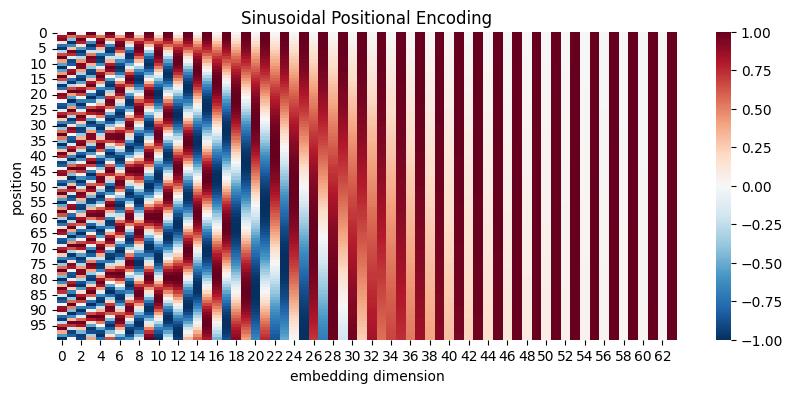

In [4]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_hid, n_position=200):
        super().__init__()
        self.register_buffer('pos_table', self._get_sinusoid_encoding_table(n_position, d_hid))

    def _get_sinusoid_encoding_table(self, n_position, d_hid):
        def get_position_angle_vec(position):
            return [position / np.power(10000, 2 * (hid_j // 2) / d_hid) for hid_j in range(d_hid)]

        sinusoid_table = np.array([get_position_angle_vec(pos_i) for pos_i in range(n_position)])
        sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
        sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])
        return torch.FloatTensor(sinusoid_table).unsqueeze(0)

    def forward(self, x):
        return x + self.pos_table[:, :x.size(1)].clone().detach()

pe = PositionalEncoding(d_hid=64, n_position=100)
pe_table = pe.pos_table.squeeze(0).numpy()
print('pos_table shape:', pe.pos_table.shape)
plt.figure(figsize=(10, 4))
sns.heatmap(pe_table, cmap='RdBu_r', cbar=True)
plt.xlabel('embedding dimension')
plt.ylabel('position')
plt.title('Sinusoidal Positional Encoding')
plt.show()

## 3.1 – Positional Encoding

- `d_hid` nên bằng `d_model` để phép cộng `x + pos_table` khớp shape.
- `n_position` quyết định độ dài tối đa của bảng PE.
- `register_buffer` giúp tensor được lưu trong `state_dict()` và tự chuyển thiết bị, nhưng không bị optimizer cập nhật.
- Sinusoidal PE cho phép ngoại suy sang độ dài lớn hơn khi suy luận.

In [5]:
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_in, d_hid, dropout=0.1):
        super().__init__()
        self.w_1 = nn.Linear(d_in, d_hid)
        self.w_2 = nn.Linear(d_hid, d_in)
        self.layer_norm = nn.LayerNorm(d_in, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        residual = x
        x = self.w_2(F.relu(self.w_1(x)))
        x = self.dropout(x)
        x = self.layer_norm(x + residual)
        return x

class EncoderLayer(nn.Module):
    def __init__(self, d_model, d_inner, n_head, d_k, d_v, dropout=0.1):
        super().__init__()
        self.slf_attn = MultiHeadAttention(n_head, d_model, d_k, d_v, dropout=dropout)
        self.pos_ffn = PositionwiseFeedForward(d_model, d_inner, dropout=dropout)

    def forward(self, enc_input, slf_attn_mask=None):
        enc_output, enc_slf_attn = self.slf_attn(enc_input, enc_input, enc_input, mask=slf_attn_mask)
        enc_output = self.pos_ffn(enc_output)
        return enc_output, enc_slf_attn

class DecoderLayer(nn.Module):
    def __init__(self, d_model, d_inner, n_head, d_k, d_v, dropout=0.1):
        super().__init__()
        self.slf_attn = MultiHeadAttention(n_head, d_model, d_k, d_v, dropout=dropout)
        self.enc_attn = MultiHeadAttention(n_head, d_model, d_k, d_v, dropout=dropout)
        self.pos_ffn = PositionwiseFeedForward(d_model, d_inner, dropout=dropout)

    def forward(self, dec_input, enc_output, slf_attn_mask=None, dec_enc_attn_mask=None):
        dec_output, dec_slf_attn = self.slf_attn(dec_input, dec_input, dec_input, mask=slf_attn_mask)
        dec_output, dec_enc_attn = self.enc_attn(dec_output, enc_output, enc_output, mask=dec_enc_attn_mask)
        dec_output = self.pos_ffn(dec_output)
        return dec_output, dec_slf_attn, dec_enc_attn

enc_layer = EncoderLayer(512, 2048, 8, 64, 64).to(device)
dec_layer = DecoderLayer(512, 2048, 8, 64, 64).to(device)
enc_in = torch.randn(2, 10, 512).to(device)
enc_out, enc_attn = enc_layer(enc_in)
dec_out, dec_self_attn, dec_enc_attn = dec_layer(enc_in, enc_out)
print('Encoder output:', enc_out.shape)
print('Encoder attn:', enc_attn.shape)
print('Decoder output:', dec_out.shape)
print('Decoder cross attn:', dec_enc_attn.shape)
print('Encoder layer params:', sum(p.numel() for p in enc_layer.parameters()))
print('Decoder layer params:', sum(p.numel() for p in dec_layer.parameters()))

Encoder output: torch.Size([2, 10, 512])
Encoder attn: torch.Size([2, 8, 10, 10])
Decoder output: torch.Size([2, 10, 512])
Decoder cross attn: torch.Size([2, 8, 10, 10])
Encoder layer params: 3150336
Decoder layer params: 4199936


## 5.1 và 6.1 – Encoder/Decoder + Transformer

- `d_inner` là chiều ẩn của FFN, không xuất hiện trong MHA.
- Encoder Layer giữ nguyên shape `[batch, seq_len, d_model]` qua các sub-layer.
- Decoder có masked self-attention và cross-attention.
- Các phép residual, LayerNorm, Dropout được đặt sau từng sub-layer theo kiến trúc Post-LN.

In [6]:
class Transformer(nn.Module):
    def __init__(self, n_src_vocab, n_tgt_vocab, src_pad_idx, tgt_pad_idx, d_word_vec=512, d_model=512, d_inner=2048, n_layers=6, n_head=8, d_k=64, d_v=64, dropout=0.1, n_position=200):
        super().__init__()
        self.src_word_emb = nn.Embedding(n_src_vocab, d_word_vec, padding_idx=src_pad_idx)
        self.tgt_word_emb = nn.Embedding(n_tgt_vocab, d_word_vec, padding_idx=tgt_pad_idx)
        self.position_enc = PositionalEncoding(d_model, n_position=n_position)
        self.dropout = nn.Dropout(p=dropout)
        self.encoder = nn.ModuleList([EncoderLayer(d_model, d_inner, n_head, d_k, d_v, dropout=dropout) for _ in range(n_layers)])
        self.decoder = nn.ModuleList([DecoderLayer(d_model, d_inner, n_head, d_k, d_v, dropout=dropout) for _ in range(n_layers)])
        self.tgt_word_prj = nn.Linear(d_model, n_tgt_vocab, bias=False)
        self.tgt_word_prj.weight = self.tgt_word_emb.weight
        nn.init.xavier_normal_(self.tgt_word_prj.weight)

    def get_pad_mask(self, seq, pad_idx):
        return (seq != pad_idx).unsqueeze(-2)

    def get_subsequent_mask(self, seq):
        sz_b, len_s = seq.size()
        return (1 - torch.triu(torch.ones((1, len_s, len_s), device=seq.device), diagonal=1)).bool()

    def forward(self, src_seq, tgt_seq):
        src_mask = self.get_pad_mask(src_seq, self.src_word_emb.padding_idx)
        tgt_mask = self.get_pad_mask(tgt_seq, self.tgt_word_emb.padding_idx) & self.get_subsequent_mask(tgt_seq)

        enc_output = self.dropout(self.position_enc(self.src_word_emb(src_seq)))
        for enc_layer in self.encoder:
            enc_output, _ = enc_layer(enc_output, slf_attn_mask=src_mask)

        dec_output = self.dropout(self.position_enc(self.tgt_word_emb(tgt_seq)))
        for dec_layer in self.decoder:
            dec_output, _, _ = dec_layer(dec_output, enc_output, slf_attn_mask=tgt_mask, dec_enc_attn_mask=src_mask)

        seq_logit = self.tgt_word_prj(dec_output)
        return seq_logit.view(-1, seq_logit.size(2))

model = Transformer(n_src_vocab=1000, n_tgt_vocab=1200, src_pad_idx=0, tgt_pad_idx=0, n_layers=2).to(device)
src_seq = torch.randint(1, 1000, (2, 10)).to(device)
tgt_seq = torch.randint(1, 1200, (2, 12)).to(device)
src_seq[0, -2:] = 0
tgt_seq[0, -3:] = 0
logits = model(src_seq, tgt_seq)
print('Logits shape:', logits.shape)
print('Total parameters:', sum(p.numel() for p in model.parameters()))

Logits shape: torch.Size([24, 1200])
Total parameters: 15826944


## 6.4 và 6.5 – Mask và Weight Tying

- `get_pad_mask` loại bỏ token padding.
- `get_subsequent_mask` tạo mặt nạ tam giác để decoder không nhìn token tương lai.
- `weight tying` dùng chung trọng số giữa embedding và projection cuối, giúp tiết kiệm tham số.

## Phần 2 – Bài toán 2: Phân loại chủ đề tiếng Việt

Em chọn **Bài toán 2** thay cho sentiment analysis: dùng bộ UIT-VSFC và dự đoán nhãn `topic` gồm 4 lớp: `lecturer`, `program`, `facility`, `others`.

Notebook dưới đây bám sát yêu cầu chấm điểm:
- Load dataset trực tiếp từ Hugging Face.
- Dùng `vinai/phobert-base` và tách từ bằng `pyvi`.
- So sánh **feature extraction** và **fine-tuning**.
- Báo cáo accuracy, F1-macro, confusion matrix, thời gian train và số tham số được cập nhật.

In [ ]:
# Cài đặt cần thiết nếu môi trường chưa có:
# !pip install -q transformers datasets scikit-learn pyvi seaborn

from collections import Counter
import time

from datasets import load_dataset
from pyvi import ViTokenizer
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

model_name = 'vinai/phobert-base'
label_names = ['lecturer', 'program', 'facility', 'others']
id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in enumerate(label_names)}

# Dùng mirror có cấu trúc ổn định, trực tiếp từ Hugging Face Hub.
raw_ds = load_dataset('tridm/UIT-VSFC')
print(raw_ds)

# Chọn subset nhỏ để notebook chạy được nhanh trên CPU/Colab miễn phí.
train_ds = raw_ds['train'].shuffle(seed=42).select(range(2000))
valid_ds = raw_ds['validation'].shuffle(seed=42).select(range(400))
test_ds = raw_ds['test'].shuffle(seed=42).select(range(400))


def segment(example):
    example['Sentence'] = ViTokenizer.tokenize(example['Sentence'])
    return example

train_ds = train_ds.map(segment)
valid_ds = valid_ds.map(segment)
test_ds = test_ds.map(segment)

print('Một vài mẫu sau khi tách từ:')
for i in range(3):
    print(f"{i+1}.", train_ds[i]['Sentence'], '| topic =', train_ds[i]['Topic'], '| label =', train_ds[i]['Encoded_topic'])

print('Phân phối nhãn train:', Counter(train_ds['Encoded_topic']))

tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)

def tokenize_fn(batch):
    return tokenizer(batch['Sentence'], truncation=True, max_length=64)

train_tok = train_ds.map(tokenize_fn, batched=True)
valid_tok = valid_ds.map(tokenize_fn, batched=True)
test_tok = test_ds.map(tokenize_fn, batched=True)

train_tok = train_tok.rename_column('Encoded_topic', 'labels')
valid_tok = valid_tok.rename_column('Encoded_topic', 'labels')
test_tok = test_tok.rename_column('Encoded_topic', 'labels')

# Giữ lại cột gốc để có thể xem lại ví dụ sai sau này.
keep_cols = ['Sentence', 'Topic', 'Sentiment', 'Encoded_sentiment', 'labels', 'input_ids', 'attention_mask']
train_tok = train_tok.remove_columns([c for c in train_tok.column_names if c not in keep_cols])
valid_tok = valid_tok.remove_columns([c for c in valid_tok.column_names if c not in keep_cols])
test_tok = test_tok.remove_columns([c for c in test_tok.column_names if c not in keep_cols])

train_tok.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
valid_tok.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
test_tok.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


def build_model(freeze_backbone=False):
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=4,
        id2label=id2label,
        label2id=label2id,
    )
    if freeze_backbone:
        for name, param in model.named_parameters():
            if not name.startswith('classifier'):
                param.requires_grad = False
    return model


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro')
    }


def train_and_eval(model, tag, num_train_epochs=2):
    args = TrainingArguments(
        output_dir=f'./{tag}_uit_vsfc_topic',
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=num_train_epochs,
        weight_decay=0.01,
        eval_strategy='epoch',
        save_strategy='no',
        logging_strategy='epoch',
        report_to='none',
        fp16=torch.cuda.is_available(),
    )
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        eval_dataset=valid_tok,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    start = time.time()
    train_result = trainer.train()
    train_time = time.time() - start
    test_result = trainer.evaluate(test_tok)
    pred = trainer.predict(test_tok)
    y_true = pred.label_ids
    y_pred = pred.predictions.argmax(axis=-1)
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=label_names, digits=4, output_dict=True)
    history = pd.DataFrame(trainer.state.log_history)
    return {
        'trainer': trainer,
        'train_result': train_result,
        'test_result': test_result,
        'y_true': y_true,
        'y_pred': y_pred,
        'cm': cm,
        'report': report,
        'history': history,
        'train_time': train_time,
        'trainable_params': trainable_params,
        'total_params': total_params,
    }

print('Sẵn sàng cho 2 chiến lược: feature extraction và fine-tuning.')